In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('all_sleep_data.csv')
df.head()

,patient_id,sleep_stage_state,start_time,end_time
0,1029,light,2023-09-08T03:32:31Z,2023-09-08T04:21:31Z
1,1029,deep,2023-09-08T04:21:31Z,2023-09-08T05:06:31Z
2,1029,light,2023-09-08T05:06:31Z,2023-09-08T05:27:31Z
3,1029,rem,2023-09-08T05:27:31Z,2023-09-08T06:55:31Z
4,1029,light,2023-09-08T06:55:31Z,2023-09-08T07:18:31Z


In [5]:
df.shape

(26579, 4)

converting start time and end time

In [6]:
# Convert to datetime (UTC)
df['start_time'] = pd.to_datetime(df['start_time'], utc=True)
df['end_time'] = pd.to_datetime(df['end_time'], utc=True)

# Convert to Indian timezone
df['start_time_ist'] = df['start_time'].dt.tz_convert('Asia/Kolkata')
df['end_time_ist'] = df['end_time'].dt.tz_convert('Asia/Kolkata')

# Create separate columns
df['start_date'] = df['start_time_ist'].dt.date
df['start_time'] = df['start_time_ist'].dt.time
df['end_date'] = df['end_time_ist'].dt.date
df['end_time'] = df['end_time_ist'].dt.time

# (Optional but useful for sleep research)
df['start_hour'] = df['start_time_ist'].dt.hour
df['start_minute'] = df['start_time_ist'].dt.minute
df['start_day_of_week'] = df['start_time_ist'].dt.day_name()
df['end_hour'] = df['end_time_ist'].dt.hour
df['end_minute'] = df['end_time_ist'].dt.minute
df['end_day_of_week'] = df['end_time_ist'].dt.day_name()

In [7]:
# Assuming your dataframe is named df
# Make sure start and end are datetime
df['start_time_ist'] = pd.to_datetime(df['start_time_ist'])
df['end_time_ist'] = pd.to_datetime(df['end_time_ist'])

# Calculate duration in hours for each row(difference first to total seconds than total hours)
df['duration_hours'] = (df['end_time_ist'] - df['start_time_ist']).dt.total_seconds() / 3600


In [8]:
def hours_minutes(decimal_hours):
    hours = int(decimal_hours)                   # integer hours
    minutes = int(round((decimal_hours - hours) * 60))  # remaining minutes
    return f"{hours}h {minutes}m"

df['duration_readable'] = df['duration_hours'].apply(hours_minutes)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26579 entries, 0 to 26578
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype                       
---  ------             --------------  -----                       
 0   patient_id         26579 non-null  int64                       
 1   sleep_stage_state  26579 non-null  object                      
 2   start_time         26579 non-null  object                      
 3   end_time           26579 non-null  object                      
 4   start_time_ist     26579 non-null  datetime64[ns, Asia/Kolkata]
 5   end_time_ist       26579 non-null  datetime64[ns, Asia/Kolkata]
 6   start_date         26579 non-null  object                      
 7   end_date           26579 non-null  object                      
 8   start_hour         26579 non-null  int32                       
 9   start_minute       26579 non-null  int32                       
 10  start_day_of_week  26579 non-null  object                 

In [10]:
pd.to_datetime(df['start_time_ist']).dt.hour.describe()

count    26579.000000
mean        14.670116
std          3.662905
min          0.000000
25%         12.000000
50%         15.000000
75%         17.000000
max         23.000000
Name: start_time_ist, dtype: float64

In [11]:
## calender date for sleep start
df['sleep_date'] = df['start_date']

In [12]:
df.tail()

,patient_id,sleep_stage_state,start_time,end_time,start_time_ist,end_time_ist,start_date,end_date,start_hour,start_minute,start_day_of_week,end_hour,end_minute,end_day_of_week,duration_hours,duration_readable,sleep_date
26574,7399,rem,16:13:31,16:16:31,2024-08-01 16:13:31+05:30,2024-08-01 16:16:31+05:30,2024-08-01,2024-08-01,16,13,Thursday,16,16,Thursday,0.050000,0h 3m,2024-08-01
26575,7399,light,16:14:31,16:21:31,2024-08-01 16:14:31+05:30,2024-08-01 16:21:31+05:30,2024-08-01,2024-08-01,16,14,Thursday,16,21,Thursday,0.116667,0h 7m,2024-08-01
26576,7399,light,16:16:31,16:31:31,2024-08-01 16:16:31+05:30,2024-08-01 16:31:31+05:30,2024-08-01,2024-08-01,16,16,Thursday,16,31,Thursday,0.250000,0h 15m,2024-08-01
26577,7399,awake,16:21:31,16:56:31,2024-08-01 16:21:31+05:30,2024-08-01 16:56:31+05:30,2024-08-01,2024-08-01,16,21,Thursday,16,56,Thursday,0.583333,0h 35m,2024-08-01
26578,7399,rem,16:31:31,17:55:31,2024-08-01 16:31:31+05:30,2024-08-01 17:55:31+05:30,2024-08-01,2024-08-01,16,31,Thursday,17,55,Thursday,1.400000,1h 24m,2024-08-01


In [13]:
# 1. Identify the duplicates where ALL THREE match
duplicates_mask = df.duplicated(subset=['patient_id', 'start_date','end_date','start_time', 'end_time'], keep='first')

# 2. Filter the dataframe
df_duplicates = df[duplicates_mask].sort_values(['patient_id', 'start_time'])

# 3. Optional: See exactly how many times each specific triplet appears
duplicate_counts = df_duplicates.groupby(['patient_id', 'start_time', 'end_time']).size().reset_index(name='occurrence_count')

print(f"Total rows involved in duplicates: {len(df_duplicates)}")
print(duplicate_counts.head())

Total rows involved in duplicates: 7204
   patient_id start_time  end_time  occurrence_count
0        1042   12:50:31  13:48:31                 2
1        1042   13:48:31  14:35:31                 2
2        1042   14:35:31  14:45:31                 2
3        1042   14:45:31  14:56:31                 2
4        1042   14:56:31  14:57:31                 2


In [14]:
# 1. Count rows before cleaning
initial_count = len(df)

# 2. Drop duplicates based on your three-column criteria
# keep='first' ensures we keep one valid copy of the data
df = df.drop_duplicates(
    subset=['patient_id', 'start_date','end_date','start_time', 'end_time'], 
    keep='first'
)

# 3. Verify the results
final_count = len(df)
print(f"Removed {initial_count - final_count} duplicate rows.")
print(f"New dataset size: {final_count} rows.")

Removed 7204 duplicate rows.
New dataset size: 19375 rows.


In [15]:
# 1. Identify the duplicates where ALL THREE match
duplicates_mask = df.duplicated(subset=['patient_id', 'start_date','end_date','start_time', 'end_time'], keep=False)

# 2. Filter the dataframe
df_duplicates = df[duplicates_mask].sort_values(['patient_id', 'start_time'])

# 3. Optional: See exactly how many times each specific triplet appears
duplicate_counts = df_duplicates.groupby(['patient_id', 'start_time', 'end_time']).size().reset_index(name='occurrence_count')

print(f"Total rows involved in duplicates: {len(df_duplicates)}")
print(duplicate_counts.head())

Total rows involved in duplicates: 0
Empty DataFrame
Columns: [patient_id, start_time, end_time, occurrence_count]
Index: []


In [16]:
print(f"Total rows in cleaned dataset: {len(df)}")

Total rows in cleaned dataset: 19375


finding total hours for each day of each patient

In [17]:
# 4. Group by patient and date to get your T2DM features
final_sleep_stats = df.groupby(['patient_id', 'sleep_date']).agg(
    total_sleep_hrs=('duration_hours', 'sum'),
    deep_sleep_hrs=('duration_hours', lambda x: x[df['sleep_stage_state'] == 'deep'].sum()),
    light_sleep_hrs=('duration_hours', lambda x: x[df['sleep_stage_state'] == 'light'].sum()),
    rem_sleep_hrs=('duration_hours', lambda x: x[df['sleep_stage_state'] == 'rem'].sum()),
    awake_hrs=('duration_hours', lambda x: x[df['sleep_stage_state'] == 'awake'].sum()),
    unknown_sleep_hrs=('duration_hours', lambda x: x[df['sleep_stage_state'] == 'unknown'].sum())
).reset_index()

In [18]:
print(f"Final sleep stats shape: {final_sleep_stats.shape}")
print(f"unique patients: {final_sleep_stats['patient_id'].nunique()}")
final_sleep_stats.head()

Final sleep stats shape: (970, 8)
unique patients: 98


,patient_id,sleep_date,total_sleep_hrs,deep_sleep_hrs,light_sleep_hrs,rem_sleep_hrs,awake_hrs,unknown_sleep_hrs
0,1029,2023-09-08,8.583333,1.116667,4.133333,3.050000,0.283333,0.0
1,1029,2023-09-09,9.683333,0.683333,5.383333,0.916667,2.700000,0.0
2,1029,2023-09-10,6.950000,1.333333,2.500000,2.000000,1.116667,0.0
3,1029,2023-09-11,8.100000,2.883333,2.700000,1.950000,0.566667,0.0
4,1029,2023-09-12,4.933333,1.316667,2.083333,1.533333,0.000000,0.0


In [19]:
final_sleep_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         970 non-null    int64  
 1   sleep_date         970 non-null    object 
 2   total_sleep_hrs    970 non-null    float64
 3   deep_sleep_hrs     970 non-null    float64
 4   light_sleep_hrs    970 non-null    float64
 5   rem_sleep_hrs      970 non-null    float64
 6   awake_hrs          970 non-null    float64
 7   unknown_sleep_hrs  970 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 60.8+ KB


Removing patients with data which are not in continous dates

In [20]:
# Ensure sleep_date is a datetime object
final_sleep_stats['sleep_date'] = pd.to_datetime(final_sleep_stats['sleep_date'])

# 1. Sort the data to check sequence
final_sleep_stats_sorted = final_sleep_stats.sort_values(['patient_id', 'sleep_date'])

# 2. Calculate the number of days and check for breaks
summary = final_sleep_stats_sorted.groupby('patient_id')['sleep_date'].agg(['nunique', 'min', 'max']).reset_index()
summary.columns = ['patient_id', 'total_days', 'start_date', 'end_date']

# 3. Logic to check for breaks: 
# (Total days between first and last) must equal (number of unique days)
summary['expected_days'] = (summary['end_date'] - summary['start_date']).dt.days + 1
summary['has_break'] = summary['expected_days'] != summary['total_days']

print(f"Total patients : {summary.shape[0]}")
print(f"no of patients with broken data: {len(summary[summary['has_break'] == True])}")
print(f"patients with continuous data: {len(summary[summary['has_break'] == False])}")
print(f"summary shape : {summary.shape}")
summary.head()
# print(summary[['patient_id', 'total_days', 'has_break']])

Total patients : 98
no of patients with broken data: 33
patients with continuous data: 65
summary shape : (98, 6)


,patient_id,total_days,start_date,end_date,expected_days,has_break
0,1029,10,2023-09-08,2023-09-18,11,True
1,1042,11,2023-10-12,2023-10-22,11,False
2,1046,11,2023-10-18,2023-10-28,11,False
3,1054,10,2023-11-01,2023-11-10,10,False
4,1055,14,2023-11-02,2023-11-15,14,False


In [21]:
broken_sleep_data=summary[summary['has_break'] == True]
continuous_sleep_data=summary[summary['has_break'] == False]
print(f"broken sleep data shape : {broken_sleep_data.shape}")
print(f"continuous sleep data shape : {continuous_sleep_data.shape}")
broken_sleep_data.head()
continuous_sleep_data.head()

broken sleep data shape : (33, 6)
continuous sleep data shape : (65, 6)


,patient_id,total_days,start_date,end_date,expected_days,has_break
1,1042,11,2023-10-12,2023-10-22,11,False
2,1046,11,2023-10-18,2023-10-28,11,False
3,1054,10,2023-11-01,2023-11-10,10,False
4,1055,14,2023-11-02,2023-11-15,14,False
5,1073,10,2023-11-30,2023-12-09,10,False


C:\Users\tushi\AppData\Local\Temp\ipykernel_12640\411557441.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  broken_sleep_data['missing_days'] = broken_sleep_data['expected_days'] - broken_sleep_data['total_days']


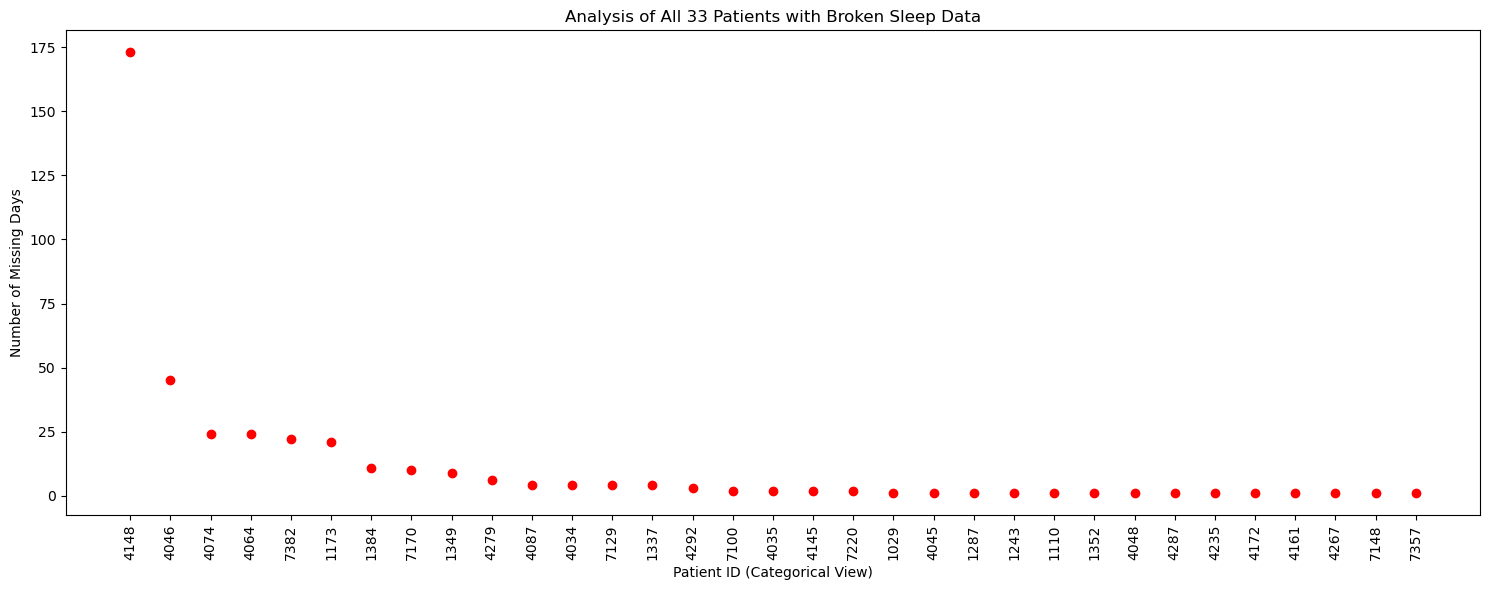

In [22]:
# 2. Calculate the 'Gap' (Missing Days)
broken_sleep_data['missing_days'] = broken_sleep_data['expected_days'] - broken_sleep_data['total_days']

# 3. Sort by missing days to make the graph readable
broken_sleep_data = broken_sleep_data.sort_values(by='missing_days', ascending=False)

# 4. FIX: Use '.astype(str)' so the X-axis treats them as categories, not numbers
plt.figure(figsize=(15, 6))
plt.scatter(broken_sleep_data['patient_id'].astype(str), broken_sleep_data['missing_days'], color='red')

plt.xlabel('Patient ID (Categorical View)')
plt.ylabel('Number of Missing Days')
plt.title(f'Analysis of All {len(broken_sleep_data)} Patients with Broken Sleep Data')
plt.xticks(rotation=90)
plt.tight_layout()

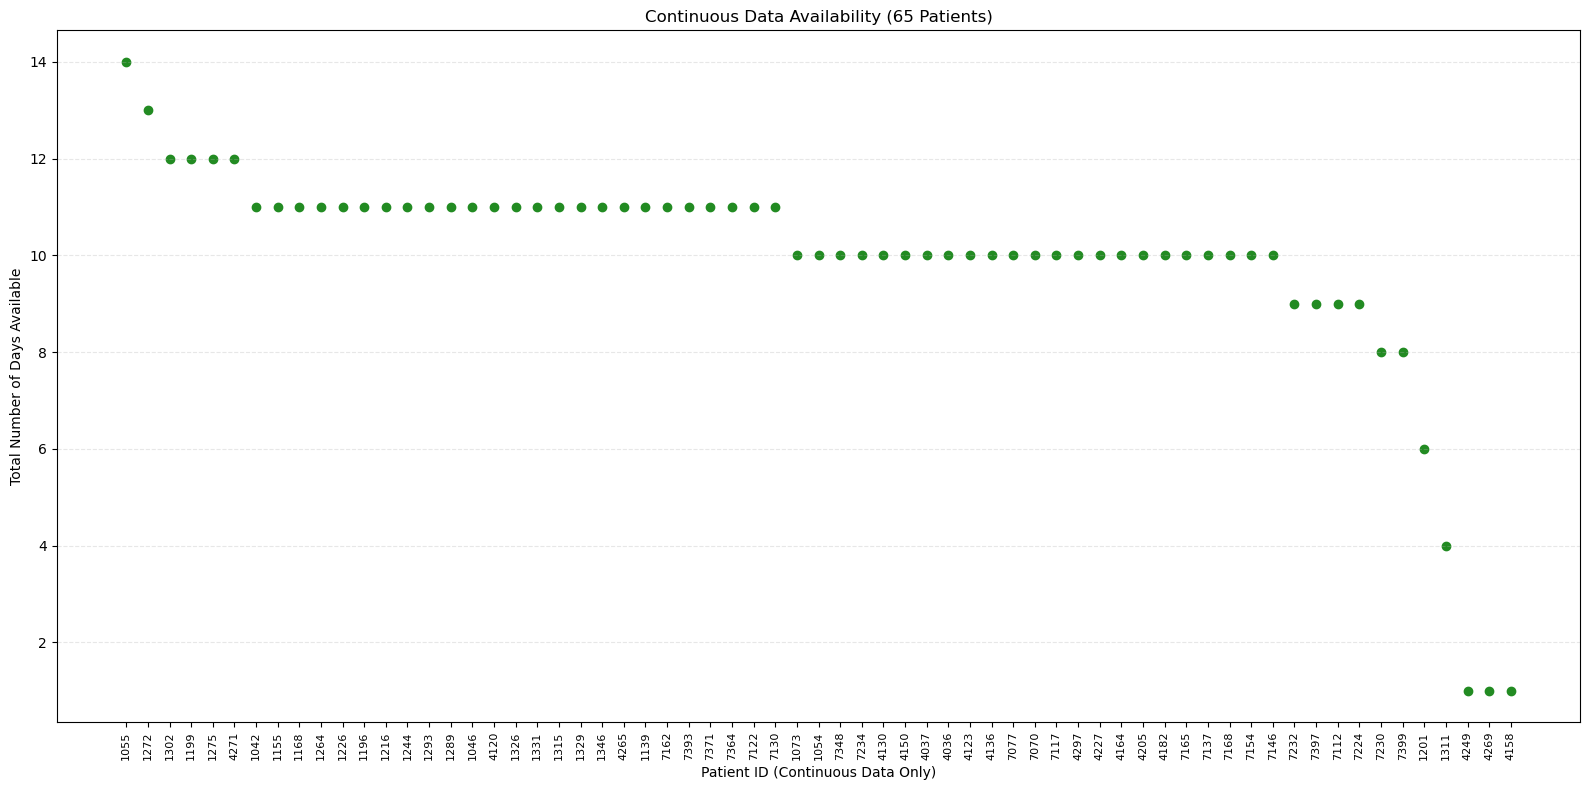

In [23]:
# 2. Sort the data so the graph flows from the longest recordings to the shortest
continuous_patients = continuous_sleep_data.sort_values(by='total_days', ascending=False)

# 3. Create the bar chart
plt.figure(figsize=(16, 8))
plt.scatter(continuous_patients['patient_id'].astype(str), continuous_patients['total_days'], color='forestgreen')

plt.xlabel('Patient ID (Continuous Data Only)')
plt.ylabel('Total Number of Days Available')
plt.title(f'Continuous Data Availability ({len(continuous_patients)} Patients)')

# Rotate IDs so they don't overlap
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
print(len(continuous_sleep_data[continuous_sleep_data['total_days'] <5]))

4


Collecting only those patients with record >=7 days 

In [25]:
# 1. Identify the 71 "Golden Patients"
# Filter summary: Continuous (has_break == False) AND total_days > 3
final_patient_ids = continuous_sleep_data[continuous_sleep_data['total_days'] >= 7]['patient_id']
print(f"Number of final patient IDs: {final_patient_ids.shape[0]}")
# 2. Create your Final Master Dataframe
df_final = final_sleep_stats[final_sleep_stats['patient_id'].isin(final_patient_ids)].copy()

# 3. Create your 2-Class Label (0 = Healthy, 1 = Diabetic/Pre-Diabetic)
# df_final['is_diabetic'] = df_final['disease_status'].apply(lambda x: 0 if x == 'healthy' else 1)

Number of final patient IDs: 60


In [26]:
df_final.head()

,patient_id,sleep_date,total_sleep_hrs,deep_sleep_hrs,light_sleep_hrs,rem_sleep_hrs,awake_hrs,unknown_sleep_hrs
10,1042,2023-10-12,8.983333,2.700000,3.683333,2.316667,0.283333,0.0
11,1042,2023-10-13,5.983333,0.333333,3.700000,1.750000,0.200000,0.0
12,1042,2023-10-14,9.733333,1.583333,5.450000,2.066667,0.633333,0.0
13,1042,2023-10-15,6.916667,3.066667,2.583333,0.750000,0.516667,0.0
14,1042,2023-10-16,3.733333,0.766667,2.616667,0.350000,0.000000,0.0


In [27]:

print(f"total final data shape : {df_final.shape}")
print(f"unique patients in final data : {df_final['patient_id'].nunique()}")
print(f"fina_sleep_data shape : {final_sleep_stats.shape}")


total final data shape : (632, 8)
unique patients in final data : 60
fina_sleep_data shape : (970, 8)


In [87]:
df_final.to_csv('final_sleep_data.csv', index=False)

Merging disease status

In [28]:
main_data=pd.read_csv('metadata_patient.csv')
main_data.head()

,person_id,clinical_site,study_group,age,study_visit_date,recommended_split,cardiac_ecg,clinical_data,environment,retinal_flio,retinal_oct,retinal_octa,retinal_photography,wearable_activity_monitor,wearable_blood_glucose
0,1029,UW,pre_diabetes_lifestyle_controlled,73,2023-09-07,train,True,True,True,True,True,True,True,True,True
1,1042,UW,healthy,40,2023-10-11,train,True,True,True,True,True,True,True,True,True
2,1046,UW,pre_diabetes_lifestyle_controlled,50,2023-10-17,train,True,True,True,True,True,True,True,True,True
3,1054,UW,healthy,71,2023-10-31,train,True,True,True,True,True,True,True,True,True
4,1055,UW,healthy,67,2023-11-01,train,True,True,True,True,True,True,True,True,True


In [29]:
mini_df=main_data[['person_id','study_group']]
mini_df.head()

,person_id,study_group
0,1029,pre_diabetes_lifestyle_controlled
1,1042,healthy
2,1046,pre_diabetes_lifestyle_controlled
3,1054,healthy
4,1055,healthy


In [30]:
# 1. Prepare your mapping dataframe (ensure person_id is unique)
# We use .set_index() so that 'person_id' becomes the key for the map
mapping_series = mini_df.set_index('person_id')['study_group']

# 2. Map the status directly to your main sleep dataframe (df)
# This replaces your entire 'disease_status' function and the .apply() call
df_final['disease_status'] = df_final['patient_id'].map(mapping_series)

In [31]:
df_final.head()

,patient_id,sleep_date,total_sleep_hrs,deep_sleep_hrs,light_sleep_hrs,rem_sleep_hrs,awake_hrs,unknown_sleep_hrs,disease_status
10,1042,2023-10-12,8.983333,2.700000,3.683333,2.316667,0.283333,0.0,healthy
11,1042,2023-10-13,5.983333,0.333333,3.700000,1.750000,0.200000,0.0,healthy
12,1042,2023-10-14,9.733333,1.583333,5.450000,2.066667,0.633333,0.0,healthy
13,1042,2023-10-15,6.916667,3.066667,2.583333,0.750000,0.516667,0.0,healthy
14,1042,2023-10-16,3.733333,0.766667,2.616667,0.350000,0.000000,0.0,healthy


In [32]:
#checking for class imbalance => 47 diabetic and 23 healthy patients
df_final['is_diabetic'] = df_final['disease_status'].apply(lambda x: 0 if x == 'healthy' else 1)
df_final.groupby('patient_id')['is_diabetic'].first().value_counts()

is_diabetic
1    38
0    22
Name: count, dtype: int64

1-  Mean sleep duration for each patient

In [33]:
diabetes_labels = df_final.groupby('patient_id')['is_diabetic'].first().reset_index()
diabetes_labels.head()

,patient_id,is_diabetic
0,1042,0
1,1046,1
2,1054,0
3,1055,0
4,1073,1


In [34]:
daily_sleep=df_final.copy()

In [35]:
daily_sleep.shape

(632, 10)

In [36]:
daily_sleep.groupby('patient_id')['total_sleep_hrs'].mean().describe()

count    60.000000
mean      8.063841
std       1.390220
min       5.671667
25%       7.391326
50%       7.870833
75%       8.430486
max      13.522727
Name: total_sleep_hrs, dtype: float64

In [37]:
daily_sleep.sort_values('total_sleep_hrs', ascending=False).head(10)

,patient_id,sleep_date,total_sleep_hrs,deep_sleep_hrs,light_sleep_hrs,rem_sleep_hrs,awake_hrs,unknown_sleep_hrs,disease_status,is_diabetic
186,1244,2024-04-30,20.150000,5.000000,8.866667,3.616667,2.666667,0.0,pre_diabetes_lifestyle_controlled,1
969,7399,2024-08-01,19.583333,7.700000,7.616667,2.566667,1.700000,0.0,oral_medication_and_or_non_insulin_injectable_...,1
810,7162,2024-02-09,18.366667,3.483333,6.566667,3.333333,4.983333,0.0,pre_diabetes_lifestyle_controlled,1
817,7162,2024-02-16,17.633333,1.300000,5.916667,5.166667,5.250000,0.0,pre_diabetes_lifestyle_controlled,1
812,7162,2024-02-11,16.783333,3.416667,4.766667,4.233333,4.366667,0.0,pre_diabetes_lifestyle_controlled,1
180,1244,2024-04-24,16.150000,4.300000,6.116667,1.683333,4.050000,0.0,pre_diabetes_lifestyle_controlled,1
181,1244,2024-04-25,15.933333,2.550000,9.700000,1.016667,2.666667,0.0,pre_diabetes_lifestyle_controlled,1
306,1329,2024-06-28,15.833333,1.200000,7.883333,2.183333,4.566667,0.0,insulin_dependent,1
179,1244,2024-04-23,15.500000,1.350000,5.516667,2.100000,6.533333,0.0,pre_diabetes_lifestyle_controlled,1
706,7077,2023-11-13,15.083333,3.366667,6.850000,3.416667,1.450000,0.0,pre_diabetes_lifestyle_controlled,1


In [38]:
mean_sleep = daily_sleep.groupby('patient_id').agg(
    mean_sleep_hrs=('total_sleep_hrs', 'mean')
).reset_index()

In [39]:
mean_sleep.head()

,patient_id,mean_sleep_hrs
0,1042,6.519697
1,1046,7.731818
2,1054,8.693333
3,1055,8.244048
4,1073,8.421667


In [40]:
mean_sleep['mean_sleep_hrs'].describe()

count    60.000000
mean      8.063841
std       1.390220
min       5.671667
25%       7.391326
50%       7.870833
75%       8.430486
max      13.522727
Name: mean_sleep_hrs, dtype: float64

In [41]:
model_data = mean_sleep.merge(
    diabetes_labels,
    on='patient_id',
    how='inner'
)

In [42]:
print(f"model data shape : {model_data.shape}")
model_data.head()

model data shape : (60, 3)


,patient_id,mean_sleep_hrs,is_diabetic
0,1042,6.519697,0
1,1046,7.731818,1
2,1054,8.693333,0
3,1055,8.244048,0
4,1073,8.421667,1


In [43]:
model_data.groupby('is_diabetic')['mean_sleep_hrs'].mean()

is_diabetic
0    7.692216
1    8.278991
Name: mean_sleep_hrs, dtype: float64

<Axes: xlabel='is_diabetic', ylabel='mean_sleep_hrs'>

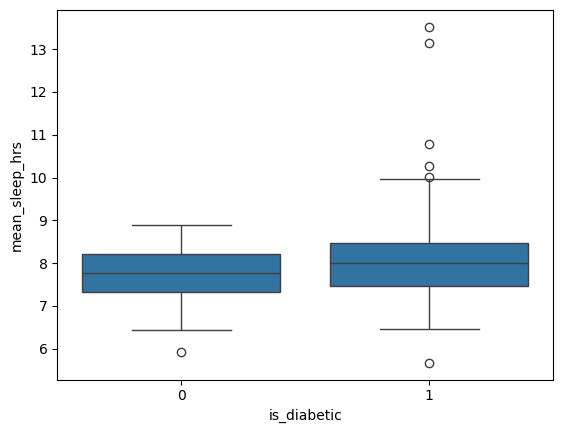

In [44]:
import seaborn as sns
sns.boxplot(x='is_diabetic', y='mean_sleep_hrs', data=model_data)

INSIGHTS
1- Both Groups Sleep Almost the Same =>  Both Groups Sleep Almost the Same  Their sleep ranges overlap a lot Sleep duration alone cannot clearly separate them(DO NO GROUP APPROX SAME TIME SO RHE HAI TOH CLASSIFIER CLASSIFY NHI KR PAYEGA KI 0 HAI YA 1 , LOW ROC AUC SCORE)
2-  Sleep duration alone cannot clearly separate them  =>  Small Difference Exists (But Not Big)
3-  Diabetes is not caused by sleep alone.
It depends on:
Weight
Diet
Activity
Age
Genetics
Sleep quality
Sleep regularity
So mean sleep alone is just one small piece.


2-  SLEEP VARIABILITY
If someone sleeps:
7, 7, 7, 7 → low variability
If someone sleeps:
4, 9, 5, 10 → high variability

Why it matters:

Irregular sleep is associated with metabolic disorders.

In [45]:
daily_sleep.columns

Index(['patient_id', 'sleep_date', 'total_sleep_hrs', 'deep_sleep_hrs',
       'light_sleep_hrs', 'rem_sleep_hrs', 'awake_hrs', 'unknown_sleep_hrs',
       'disease_status', 'is_diabetic'],
      dtype='object')

In [46]:
std_sleep = daily_sleep.groupby('patient_id').agg(
    std_sleep_hrs=('total_sleep_hrs', 'std')
).reset_index()

In [47]:
std_sleep.head()

,patient_id,std_sleep_hrs
0,1042,1.997524
1,1046,1.337794
2,1054,0.872707
3,1055,0.747920
4,1073,2.906305


In [48]:
std_sleep = std_sleep.merge(
    diabetes_labels,
    on='patient_id',
    how='inner'
)

In [49]:
std_sleep.head()

,patient_id,std_sleep_hrs,is_diabetic
0,1042,1.997524,0
1,1046,1.337794,1
2,1054,0.872707,0
3,1055,0.747920,0
4,1073,2.906305,1


In [50]:
std_sleep.groupby('is_diabetic')['std_sleep_hrs'].mean()

is_diabetic
0    1.372174
1    2.091626
Name: std_sleep_hrs, dtype: float64

<Axes: xlabel='is_diabetic', ylabel='std_sleep_hrs'>

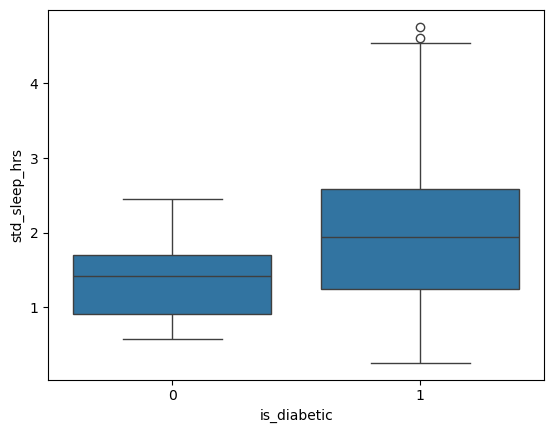

In [51]:
import seaborn as sns
sns.boxplot(x='is_diabetic', y='std_sleep_hrs', data=std_sleep)

Both features 

In [52]:
patient_level_data=model_data = model_data.merge(
    std_sleep,
    on=['patient_id','is_diabetic'],
    how='inner'
)

In [53]:
print(f"patient level data shape : {patient_level_data.shape}")
patient_level_data.head()

patient level data shape : (60, 4)


,patient_id,mean_sleep_hrs,is_diabetic,std_sleep_hrs
0,1042,6.519697,0,1.997524
1,1046,7.731818,1,1.337794
2,1054,8.693333,0,0.872707
3,1055,8.244048,0,0.747920
4,1073,8.421667,1,2.906305


In [54]:
#checking for class imbalance => 47 diabetic and 23 healthy patients
patient_level_data.groupby('patient_id')['is_diabetic'].first().value_counts()

is_diabetic
1    38
0    22
Name: count, dtype: int64

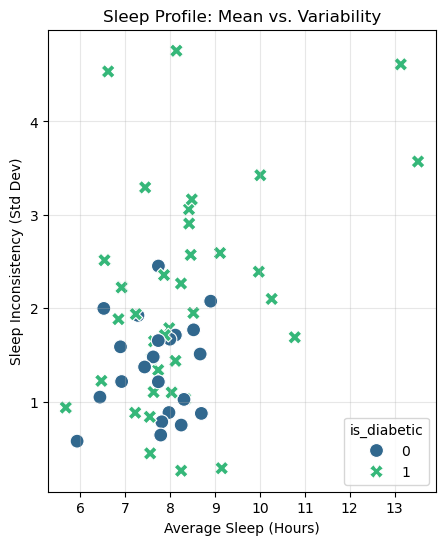

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))
sns.scatterplot(
    data=patient_level_data, 
    x='mean_sleep_hrs', 
    y='std_sleep_hrs', 
    hue='is_diabetic', 
    style='is_diabetic',
    s=100, 
    palette='viridis'
)

plt.title('Sleep Profile: Mean vs. Variability')
plt.xlabel('Average Sleep (Hours)')
plt.ylabel('Sleep Inconsistency (Std Dev)')
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
# mean sleep per patient
mean_sleep = daily_sleep.groupby('patient_id')['total_sleep_hrs'].mean()

# std sleep (variability)
std_sleep = daily_sleep.groupby('patient_id')['total_sleep_hrs'].std()

# pct short (<6 hrs)
pct_short = (daily_sleep['total_sleep_hrs'] < 6).groupby(daily_sleep['patient_id']).mean()

# pct long (>9 hrs)
pct_long = (daily_sleep['total_sleep_hrs'] > 9).groupby(daily_sleep['patient_id']).mean()

# sleep range (max - min)
sleep_range = (daily_sleep.groupby('patient_id')['total_sleep_hrs'].max()
               - daily_sleep.groupby('patient_id')['total_sleep_hrs'].min())

# number of recorded days
num_days = daily_sleep.groupby('patient_id').size()

# Combine into patient-level dataframe
patient_features = pd.DataFrame({
    'mean_sleep': mean_sleep,
    'std_sleep': std_sleep,
    'pct_short': pct_short,
    'pct_long': pct_long,
    'sleep_range': sleep_range,
    'num_days': num_days
}).reset_index()





In [57]:
patient_features.head()

,patient_id,mean_sleep,std_sleep,pct_short,pct_long,sleep_range,num_days
0,1042,6.519697,1.997524,0.272727,0.090909,6.983333,11
1,1046,7.731818,1.337794,0.090909,0.181818,4.216667,11
2,1054,8.693333,0.872707,0.000000,0.200000,3.166667,10
3,1055,8.244048,0.747920,0.000000,0.142857,3.133333,14
4,1073,8.421667,2.906305,0.200000,0.400000,9.233333,10


In [58]:
# Merge diabetes labels
patient_features = patient_features.merge(diabetes_labels, on='patient_id', how='inner')
patient_features.head()

,patient_id,mean_sleep,std_sleep,pct_short,pct_long,sleep_range,num_days,is_diabetic
0,1042,6.519697,1.997524,0.272727,0.090909,6.983333,11,0
1,1046,7.731818,1.337794,0.090909,0.181818,4.216667,11,1
2,1054,8.693333,0.872707,0.000000,0.200000,3.166667,10,0
3,1055,8.244048,0.747920,0.000000,0.142857,3.133333,14,0
4,1073,8.421667,2.906305,0.200000,0.400000,9.233333,10,1


In [59]:
daily_sleep[daily_sleep['total_sleep_hrs'] == 0]

,patient_id,sleep_date,total_sleep_hrs,deep_sleep_hrs,light_sleep_hrs,rem_sleep_hrs,awake_hrs,unknown_sleep_hrs,disease_status,is_diabetic


In [60]:
daily_sleep['pct_deep'] = daily_sleep['deep_sleep_hrs'] / daily_sleep['total_sleep_hrs']
daily_sleep['pct_rem'] = daily_sleep['rem_sleep_hrs'] / daily_sleep['total_sleep_hrs']
daily_sleep['pct_light'] = daily_sleep['light_sleep_hrs'] / daily_sleep['total_sleep_hrs']
daily_sleep['pct_awake'] = daily_sleep['awake_hrs'] / daily_sleep['total_sleep_hrs']

In [61]:
daily_sleep.head()


,patient_id,sleep_date,total_sleep_hrs,deep_sleep_hrs,light_sleep_hrs,rem_sleep_hrs,awake_hrs,unknown_sleep_hrs,disease_status,is_diabetic,pct_deep,pct_rem,pct_light,pct_awake
10,1042,2023-10-12,8.983333,2.700000,3.683333,2.316667,0.283333,0.0,healthy,0,0.300557,0.257885,0.410019,0.031540
11,1042,2023-10-13,5.983333,0.333333,3.700000,1.750000,0.200000,0.0,healthy,0,0.055710,0.292479,0.618384,0.033426
12,1042,2023-10-14,9.733333,1.583333,5.450000,2.066667,0.633333,0.0,healthy,0,0.162671,0.212329,0.559932,0.065068
13,1042,2023-10-15,6.916667,3.066667,2.583333,0.750000,0.516667,0.0,healthy,0,0.443373,0.108434,0.373494,0.074699
14,1042,2023-10-16,3.733333,0.766667,2.616667,0.350000,0.000000,0.0,healthy,0,0.205357,0.093750,0.700893,0.000000


In [62]:
stage_features = daily_sleep.groupby('patient_id')[[
    'pct_deep','pct_rem','pct_light','pct_awake'
]].mean().reset_index()

In [63]:
stage_features.head()

,patient_id,pct_deep,pct_rem,pct_light,pct_awake
0,1042,0.272408,0.182807,0.467213,0.077571
1,1046,0.198946,0.161459,0.441006,0.184562
2,1054,0.257823,0.198659,0.341224,0.202294
3,1055,0.205835,0.168771,0.474803,0.150591
4,1073,0.228096,0.088586,0.285554,0.397764


In [64]:
final_patient_features = patient_features.merge(
    stage_features,
    on='patient_id',
    how='inner' 
)

In [65]:
final_patient_features.head()

,patient_id,mean_sleep,std_sleep,pct_short,pct_long,sleep_range,num_days,is_diabetic,pct_deep,pct_rem,pct_light,pct_awake
0,1042,6.519697,1.997524,0.272727,0.090909,6.983333,11,0,0.272408,0.182807,0.467213,0.077571
1,1046,7.731818,1.337794,0.090909,0.181818,4.216667,11,1,0.198946,0.161459,0.441006,0.184562
2,1054,8.693333,0.872707,0.000000,0.200000,3.166667,10,0,0.257823,0.198659,0.341224,0.202294
3,1055,8.244048,0.747920,0.000000,0.142857,3.133333,14,0,0.205835,0.168771,0.474803,0.150591
4,1073,8.421667,2.906305,0.200000,0.400000,9.233333,10,1,0.228096,0.088586,0.285554,0.397764


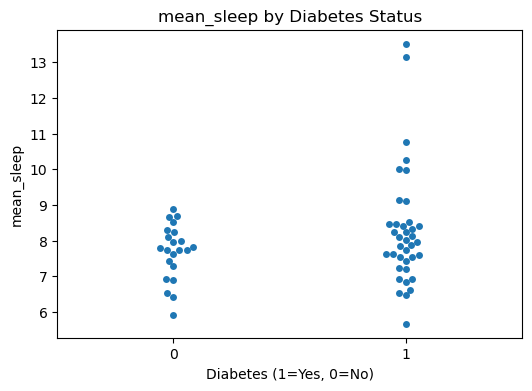

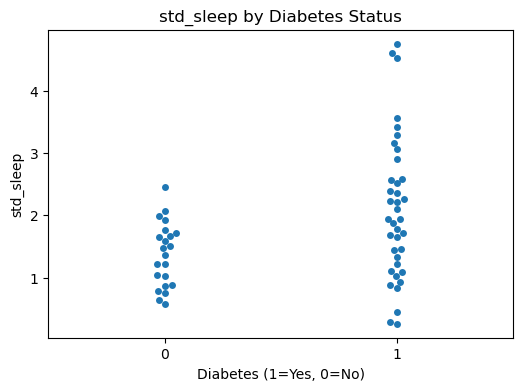

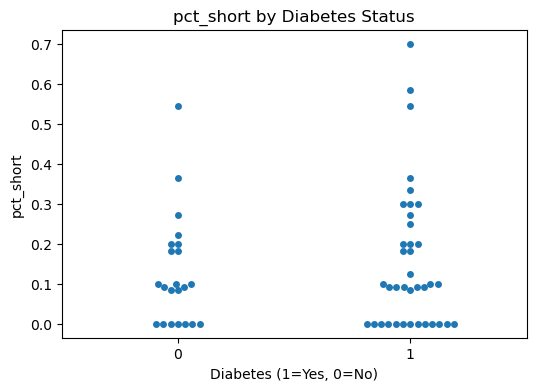

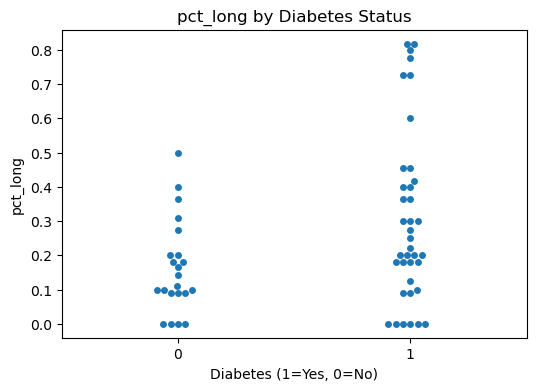

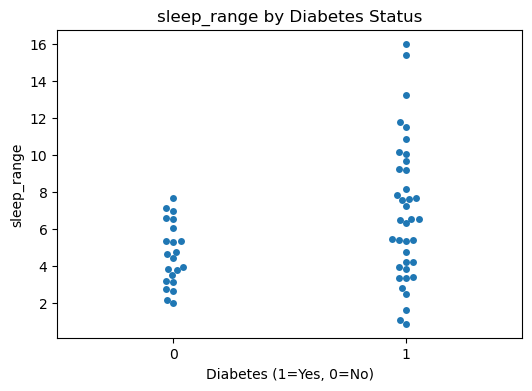

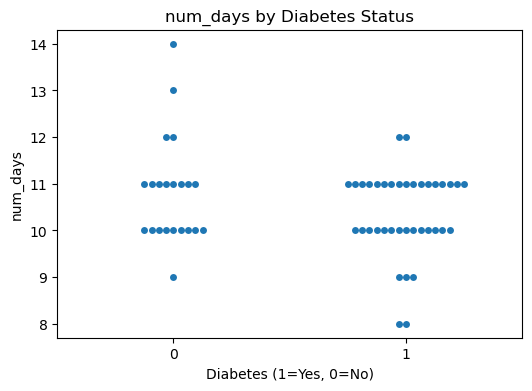

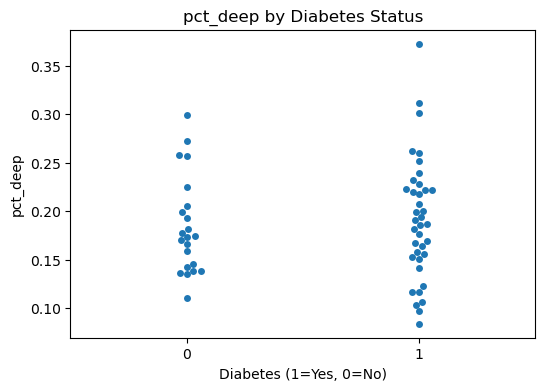

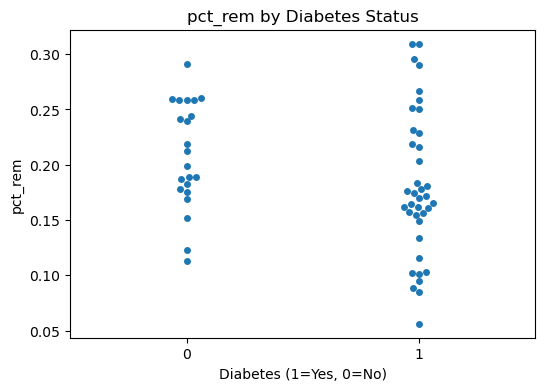

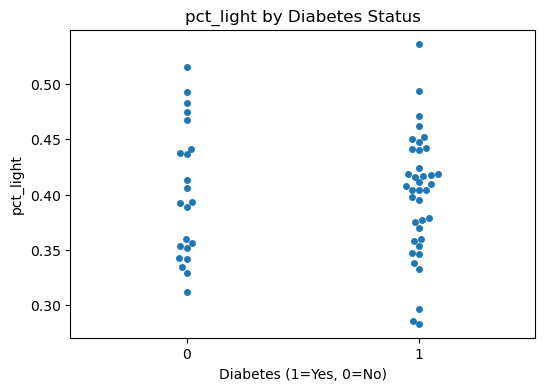

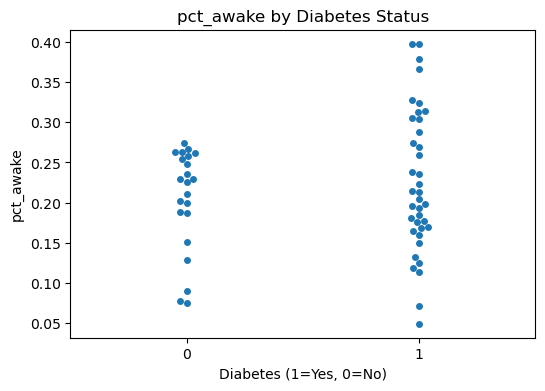

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['mean_sleep','std_sleep','pct_short','pct_long','sleep_range','num_days','pct_deep','pct_rem','pct_light','pct_awake']

for f in features:
    plt.figure(figsize=(6,4))
    sns.swarmplot(x='is_diabetic', y=f, data=final_patient_features)
    plt.title(f'{f} by Diabetes Status')
    plt.xlabel("Diabetes (1=Yes, 0=No)")
    plt.show()

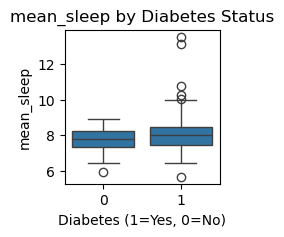

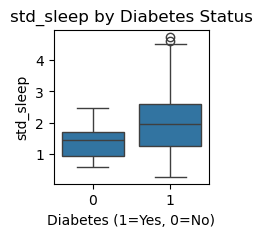

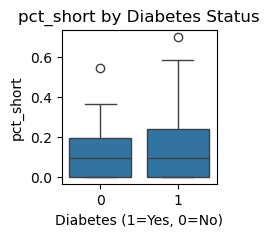

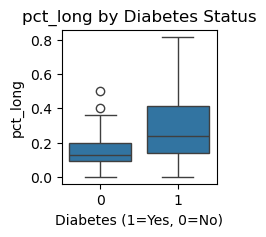

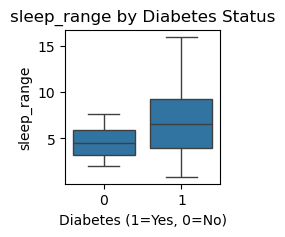

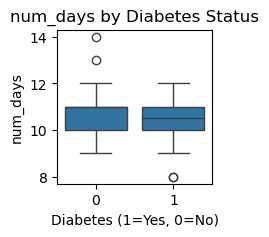

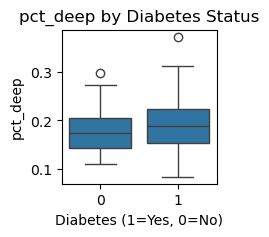

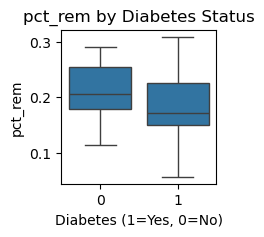

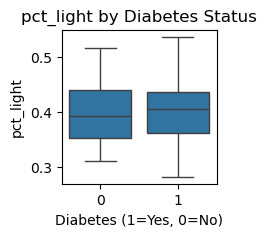

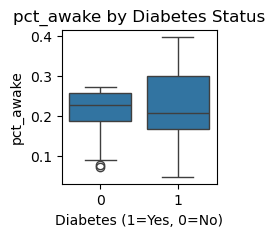

In [67]:
for f in features:
    plt.figure(figsize=(2,2))
    sns.boxplot(x='is_diabetic', y=f, data=final_patient_features)
    plt.title(f'{f} by Diabetes Status')
    plt.xlabel("Diabetes (1=Yes, 0=No)")
    plt.show()

In [68]:
# p < 0.05 → feature significantly separates diabetics from non-diabetics
# Helps you trust which features to feed into classifier
from scipy.stats import mannwhitneyu

for f in features:
    group1 = final_patient_features[final_patient_features['is_diabetic']==1][f]
    group0 = final_patient_features[final_patient_features['is_diabetic']==0][f]
    stat, p = mannwhitneyu(group1, group0)
    print(f"{f} Mann-Whitney U p-value = {p:.4f}")

mean_sleep Mann-Whitney U p-value = 0.3077
std_sleep Mann-Whitney U p-value = 0.0081
pct_short Mann-Whitney U p-value = 0.7304
pct_long Mann-Whitney U p-value = 0.0241
sleep_range Mann-Whitney U p-value = 0.0135
num_days Mann-Whitney U p-value = 0.3004
pct_deep Mann-Whitney U p-value = 0.5651
pct_rem Mann-Whitney U p-value = 0.0421
pct_light Mann-Whitney U p-value = 0.8002
pct_awake Mann-Whitney U p-value = 0.6731


In [69]:
for f in features:
    print(f"Mean {f} by Diabetes Status:")
    print(final_patient_features.groupby('is_diabetic')[f].mean())
    print()

Mean mean_sleep by Diabetes Status:
is_diabetic
0    7.692216
1    8.278991
Name: mean_sleep, dtype: float64

Mean std_sleep by Diabetes Status:
is_diabetic
0    1.372174
1    2.091626
Name: std_sleep, dtype: float64

Mean pct_short by Diabetes Status:
is_diabetic
0    0.128007
1    0.154605
Name: pct_short, dtype: float64

Mean pct_long by Diabetes Status:
is_diabetic
0    0.163684
1    0.307915
Name: pct_long, dtype: float64

Mean sleep_range by Diabetes Status:
is_diabetic
0    4.609735
1    6.850877
Name: sleep_range, dtype: float64

Mean num_days by Diabetes Status:
is_diabetic
0    10.818182
1    10.368421
Name: num_days, dtype: float64

Mean pct_deep by Diabetes Status:
is_diabetic
0    0.184439
1    0.191848
Name: pct_deep, dtype: float64

Mean pct_rem by Diabetes Status:
is_diabetic
0    0.209078
1    0.180900
Name: pct_rem, dtype: float64

Mean pct_light by Diabetes Status:
is_diabetic
0    0.401082
1    0.399518
Name: pct_light, dtype: float64

Mean pct_awake by Diabetes Sta

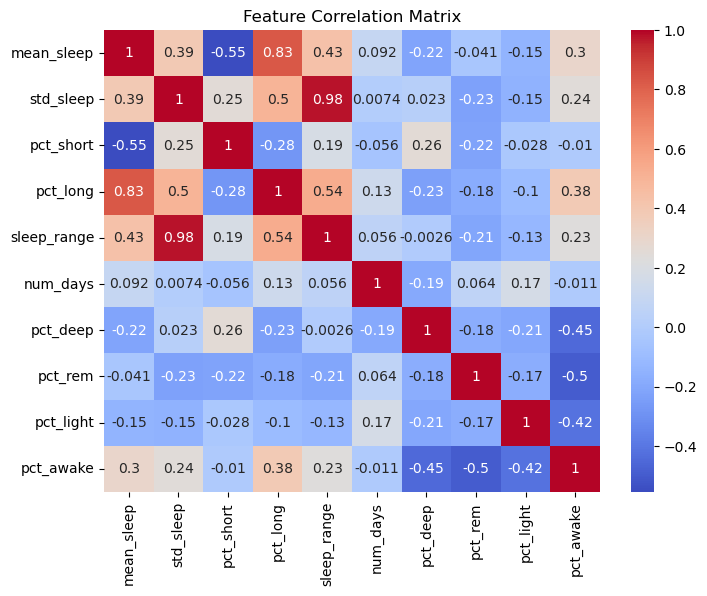

In [70]:
plt.figure(figsize=(8,6))
sns.heatmap(final_patient_features[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [71]:
final_patient_features.columns

Index(['patient_id', 'mean_sleep', 'std_sleep', 'pct_short', 'pct_long',
       'sleep_range', 'num_days', 'is_diabetic', 'pct_deep', 'pct_rem',
       'pct_light', 'pct_awake'],
      dtype='object')

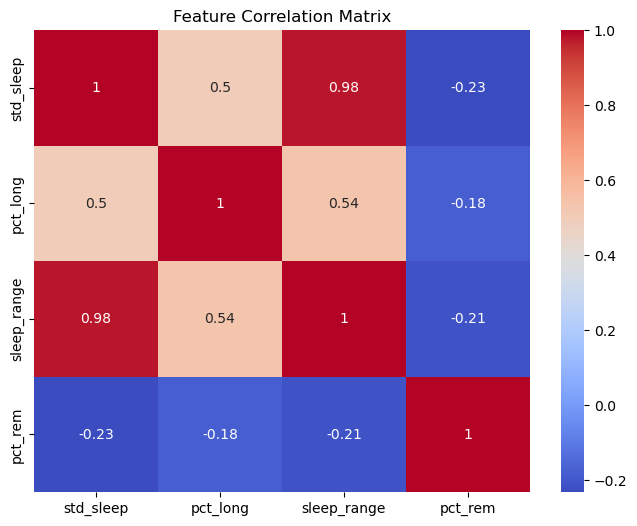

In [72]:
features2=['std_sleep','pct_long','sleep_range','pct_rem']
plt.figure(figsize=(8,6))
sns.heatmap(final_patient_features[features2].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [73]:
print(f"final_patient_features shape: {final_patient_features.shape}")
final_patient_features.head()

final_patient_features shape: (60, 12)


,patient_id,mean_sleep,std_sleep,pct_short,pct_long,sleep_range,num_days,is_diabetic,pct_deep,pct_rem,pct_light,pct_awake
0,1042,6.519697,1.997524,0.272727,0.090909,6.983333,11,0,0.272408,0.182807,0.467213,0.077571
1,1046,7.731818,1.337794,0.090909,0.181818,4.216667,11,1,0.198946,0.161459,0.441006,0.184562
2,1054,8.693333,0.872707,0.000000,0.200000,3.166667,10,0,0.257823,0.198659,0.341224,0.202294
3,1055,8.244048,0.747920,0.000000,0.142857,3.133333,14,0,0.205835,0.168771,0.474803,0.150591
4,1073,8.421667,2.906305,0.200000,0.400000,9.233333,10,1,0.228096,0.088586,0.285554,0.397764


TRANING

In [74]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [75]:
# Define feature sets
feature_sets = {
    "Model_1": ["std_sleep"],
    "Model_2": ["std_sleep", "pct_long"],
    "Model_3": ["std_sleep", "pct_long", "pct_rem"]
}
y = final_patient_features['is_diabetic']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, features in feature_sets.items():
    
    X = final_patient_features[features]
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced"))
    ])
    
    auc_scores = cross_val_score(
        pipeline, X, y,
        cv=skf,
        scoring="roc_auc"
    )
    
    print(f"{name}")
    print("Mean AUC:", np.mean(auc_scores))
    print("Std AUC:", np.std(auc_scores))
    print("-------------")

Model_1
Mean AUC: 0.6908928571428572
Std AUC: 0.23598901738540845
-------------
Model_2
Mean AUC: 0.6960714285714286
Std AUC: 0.22353947740652808
-------------
Model_3
Mean AUC: 0.7101785714285714
Std AUC: 0.17245377966994224
-------------


In [76]:
from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

auc_scores = cross_val_score(
    pipeline,
    final_patient_features[["std_sleep", "pct_long", "pct_rem"]],
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))

Mean AUC: 0.6995
Std AUC: 0.13010202040816168


In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
# Define feature sets
feature_sets = {
    "Model_1": ["std_sleep"],
    "Model_2": ["std_sleep", "pct_long"],
    "Model_3": ["std_sleep", "pct_long", "pct_rem"]
}
y = final_patient_features['is_diabetic']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, features in feature_sets.items():
    
    X = final_patient_features[features]
    
    pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])
    auc_scores = cross_val_score(
        pipeline, X, y,
        cv=skf,
        scoring="roc_auc"
    )
    
    print(f"{name}")
    print("Mean AUC:", np.mean(auc_scores))
    print("Std AUC:", np.std(auc_scores))
    print("-------------")

Model_1
Mean AUC: 0.5463392857142857
Std AUC: 0.1413944087527177
-------------
Model_2
Mean AUC: 0.5717857142857142
Std AUC: 0.10787377177866316
-------------
Model_3
Mean AUC: 0.5923214285714286
Std AUC: 0.10921303605750532
-------------


In [79]:
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [80]:

X = final_patient_features[["std_sleep", "pct_long", "pct_rem"]]
y = final_patient_features["is_diabetic"]

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)
models = {

    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
        ]),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 3, 5],
            "min_samples_split": [2, 5]
        }
    ),

    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(class_weight="balanced", probability=True))
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    ),

    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    )
}

results = {}

for name, (model, params) in models.items():
    
    grid = GridSearchCV(
        model,
        params,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    grid.fit(X, y)
    
    results[name] = {
        "Best AUC": grid.best_score_,
        "Best Params": grid.best_params_
    }

for name, result in results.items():
    print(f"{name}")
    print("Best AUC:", result["Best AUC"])
    print("Best Params:", result["Best Params"])
    print("------------")



Logistic Regression
Best AUC: 0.7326428571428572
Best Params: {'model__C': 0.01, 'model__penalty': 'l2'}
------------
Random Forest
Best AUC: 0.6993571428571428
Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
------------
SVM
Best AUC: 0.7544107142857144
Best Params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
------------
KNN
Best AUC: 0.6848482142857142
Best Params: {'model__n_neighbors': 5, 'model__weights': 'uniform'}
------------


In [81]:
from sklearn.model_selection import cross_val_score

In [82]:
best_model = grid.best_estimator_  # after SVM grid

auc_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))

Mean AUC: 0.6848482142857142
Std AUC: 0.12103765891505733


In [83]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [84]:
# -------------------------------
# Data
# -------------------------------
X = final_patient_features[["std_sleep", "pct_long", "pct_rem"]]
y = final_patient_features["is_diabetic"]

# -------------------------------
# Cross Validation Strategy
# -------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------
# Models + Hyperparameters
# -------------------------------
models = {

    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
        ]),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 3, 5],
            "min_samples_split": [2, 5]
        }
    ),

    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(class_weight="balanced", probability=True))
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    ),

    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    )
}

# -------------------------------
# Grid Search + Store Best Models
# -------------------------------
best_models = {}
results = {}

for name, (model, params) in models.items():
    
    grid = GridSearchCV(
        model,
        params,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    
    results[name] = {
        "Best AUC (CV Mean)": grid.best_score_,
        "Best Params": grid.best_params_
    }
    
# -------------------------------
# Print Tuning Results
# -------------------------------
print("\n===== Hyperparameter Tuning Results =====\n")
for name, result in results.items():
    print(name)
    print("Best AUC (CV Mean):", round(result["Best AUC (CV Mean)"], 4))
    print("Best Params:", result["Best Params"])
    print("------------")

# -------------------------------
# Re-evaluate Stability of Each Best Model
# -------------------------------
print("\n===== Stability Check (Repeated CV) =====\n")

final_scores = {}

for name, model in best_models.items():
    
    auc_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    
    final_scores[name] = mean_auc
    
    print(name)
    print("Mean AUC:", round(mean_auc, 4))
    print("Std AUC:", round(std_auc, 4))
    print("------------")

# -------------------------------
# Final Winner
# -------------------------------
best_model_name = max(final_scores, key=final_scores.get)

print("\n🏆 FINAL BEST MODEL:", best_model_name)
print("Final Mean AUC:", round(final_scores[best_model_name], 4))




===== Hyperparameter Tuning Results =====

Logistic Regression
Best AUC (CV Mean): 0.7273
Best Params: {'model__C': 0.01, 'model__penalty': 'l2'}
------------
Random Forest
Best AUC (CV Mean): 0.6368
Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}
------------
SVM
Best AUC (CV Mean): 0.7471
Best Params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
------------
KNN
Best AUC (CV Mean): 0.6691
Best Params: {'model__n_neighbors': 5, 'model__weights': 'uniform'}
------------

===== Stability Check (Repeated CV) =====

Logistic Regression
Mean AUC: 0.7273
Std AUC: 0.1734
------------
Random Forest
Mean AUC: 0.6368
Std AUC: 0.1387
------------
SVM
Mean AUC: 0.7471
Std AUC: 0.1005
------------
KNN
Mean AUC: 0.6691
Std AUC: 0.1068
------------

🏆 FINAL BEST MODEL: SVM
Final Mean AUC: 0.7471


FINAL TRANING

In [85]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,f1_score,accuracy_score,precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [86]:
# -----------------------
# Features and target
# -----------------------
X = final_patient_features[["std_sleep", "pct_long", "pct_rem"]]
y = final_patient_features["is_diabetic"]

# -----------------------
# Train-Test Split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------
# Final Best Model (SVM from tuning)
# -----------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=0.1,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        probability=True
    ))
])

# -----------------------
# Train
# -----------------------
final_model.fit(X_train, y_train)

# -----------------------
# Predict
# -----------------------
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 0]

# -----------------------
# Evaluation
# -----------------------
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("=== ROC AUC ===")
print(roc_auc_score(y_test, y_prob))

print("=== Additional Metrics ===")
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.73      1.00      0.84         8

    accuracy                           0.75        12
   macro avg       0.86      0.62      0.62        12
weighted avg       0.82      0.75      0.69        12

=== Confusion Matrix ===
[[1 3]
 [0 8]]
=== ROC AUC ===
0.71875
=== Additional Metrics ===
F1 Score: 0.8421
Accuracy: 0.75
Precision: 0.7273
Recall: 1.0
